<a href="https://colab.research.google.com/github/ZainSiddique291/BERT_Full_Finetuning_vs_LoRA_Sentiment_Analysis.ipynb/blob/main/BERT_Full_Finetuning_vs_LoRA_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q transformers datasets accelerate evaluate peft

In [3]:
import os
import time
import json
import torch
import numpy as np
import pandas as pd

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [4]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [5]:
train_test = dataset["train"].train_test_split(
    test_size=0.1,
    seed=42
)

train_dataset = train_test["train"]
validation_dataset = train_test["test"]
test_dataset = dataset["test"]

print("Training:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Testing:", len(test_dataset))

Training: 22500
Validation: 2500
Testing: 25000


In [6]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_validation = validation_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [8]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [9]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [10]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


total_params, trainable_params = count_parameters(model)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 109483778
Trainable parameters: 109483778


In [11]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

In [12]:
full_training_args = TrainingArguments(
    output_dir="./bert_full_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    report_to="none",

    fp16=torch.cuda.is_available()
)

In [13]:
full_trainer = Trainer(
    model=model,

    args=full_training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_validation,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [14]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

start_time = time.perf_counter()

train_result_full = full_trainer.train()

end_time = time.perf_counter()

full_training_time = end_time - start_time

print(
    f"Full Fine-Tuning Training Time: "
    f"{full_training_time:.2f} seconds"
)
print(
    f"Full Fine-Tuning Training Time: "
    f"{full_training_time / 60:.2f} minutes"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.252916,0.231642,0.911200,0.917676,0.904535,0.911058
2,0.151453,0.298403,0.919600,0.921725,0.918059,0.919888


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Full Fine-Tuning Training Time: 737.81 seconds
Full Fine-Tuning Training Time: 12.30 minutes


In [15]:
if torch.cuda.is_available():

    peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3)

    print(
        f"Peak GPU Memory Used: "
        f"{peak_memory:.2f} GB"
    )

else:
    print("GPU not available")

Peak GPU Memory Used: 3.03 GB


In [16]:
full_results = full_trainer.evaluate(
    tokenized_test
)

print("\nFull Fine-Tuning Results:")

for key, value in full_results.items():
    print(key, ":", value)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.151453,0.264207,2,0.922280,0.916976,0.928640,0.922771



Full Fine-Tuning Results:
eval_loss : 0.2642074525356293
eval_accuracy : 0.92228
eval_precision : 0.916976064460068
eval_recall : 0.92864
eval_f1 : 0.9227711753249335


In [17]:
full_model_path = "./bert_full_model"

full_trainer.save_model(full_model_path)
tokenizer.save_pretrained(full_model_path)

print("Full model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full model saved.


In [18]:
def get_folder_size(path):
    total_size = 0

    for root, dirs, files in os.walk(path):
        for file in files:
            file_path = os.path.join(root, file)

            if os.path.exists(file_path):
                total_size += os.path.getsize(file_path)

    return total_size / (1024 ** 2)


full_model_size = get_folder_size(full_model_path)

print(
    f"Full Fine-Tuned Model Size: "
    f"{full_model_size:.2f} MB"
)

Full Fine-Tuned Model Size: 418.35 MB


In [19]:
lora_base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,

    r=8,

    lora_alpha=16,

    lora_dropout=0.1,

    target_modules=["query", "value"],

    bias="none",

    modules_to_save=["classifier"]
)

In [21]:
!pip install --upgrade torchao

In [22]:
lora_model = get_peft_model(
    lora_base_model,
    lora_config
)

lora_model.print_trainable_parameters()

trainable params: 296,450 || all params: 109,780,228 || trainable%: 0.2700


In [23]:
lora_total_params, lora_trainable_params = count_parameters(
    lora_model
)

print("LoRA Total Parameters:", lora_total_params)
print("LoRA Trainable Parameters:", lora_trainable_params)

print(
    "Trainable Percentage:",
    (lora_trainable_params / lora_total_params) * 100,
    "%"
)

LoRA Total Parameters: 109780228
LoRA Trainable Parameters: 296450
Trainable Percentage: 0.2700395193203643 %


In [24]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

In [25]:
lora_training_args = TrainingArguments(
    output_dir="./bert_lora_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    report_to="none",

    fp16=torch.cuda.is_available()
)

In [27]:
lora_trainer = Trainer(
    model=lora_model,

    args=lora_training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_validation,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [28]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

start_time = time.perf_counter()

train_result_lora = lora_trainer.train()

end_time = time.perf_counter()

lora_training_time = end_time - start_time

print(
    f"LoRA Training Time: "
    f"{lora_training_time:.2f} seconds"
)

print(
    f"LoRA Training Time: "
    f"{lora_training_time / 60:.2f} minutes"
)

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.348668,0.317183,0.868000,0.884010,0.848846,0.866071
2,0.326892,0.299318,0.876000,0.874901,0.879077,0.876984


LoRA Training Time: 541.19 seconds
LoRA Training Time: 9.02 minutes


In [29]:
if torch.cuda.is_available():

    lora_peak_memory = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 3)
    )

    print(
        f"LoRA Peak GPU Memory Used: "
        f"{lora_peak_memory:.2f} GB"
    )

LoRA Peak GPU Memory Used: 3.08 GB


In [30]:
lora_results = lora_trainer.evaluate(
    tokenized_test
)

print("\nLoRA Results:")

for key, value in lora_results.items():
    print(key, ":", value)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.326892,0.300966,2,0.875320,0.859916,0.896720,0.877932



LoRA Results:
eval_loss : 0.30096617341041565
eval_accuracy : 0.87532
eval_precision : 0.859915611814346
eval_recall : 0.89672
eval_f1 : 0.8779322498531428


In [31]:
lora_model_path = "./bert_lora_model"

lora_trainer.save_model(lora_model_path)
tokenizer.save_pretrained(lora_model_path)

print("LoRA model saved.")

LoRA model saved.


In [32]:
lora_model_size = get_folder_size(lora_model_path)

print(
    f"LoRA Model Size: "
    f"{lora_model_size:.2f} MB"
)

LoRA Model Size: 1.83 MB


In [33]:
comparison = pd.DataFrame({
    "Metric": [
        "Total Parameters",
        "Trainable Parameters",
        "Trainable Percentage",
        "Training Time (seconds)",
        "Training Time (minutes)",
        "Peak GPU Memory (GB)",
        "Model Storage (MB)",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Full Fine-Tuning": [
        total_params,
        trainable_params,
        (trainable_params / total_params) * 100,
        full_training_time,
        full_training_time / 60,
        peak_memory,
        full_model_size,
        full_results["eval_accuracy"],
        full_results["eval_precision"],
        full_results["eval_recall"],
        full_results["eval_f1"]
    ],

    "LoRA": [
        lora_total_params,
        lora_trainable_params,
        (lora_trainable_params / lora_total_params) * 100,
        lora_training_time,
        lora_training_time / 60,
        lora_peak_memory,
        lora_model_size,
        lora_results["eval_accuracy"],
        lora_results["eval_precision"],
        lora_results["eval_recall"],
        lora_results["eval_f1"]
    ]
})

comparison

,Metric,Full Fine-Tuning,LoRA
0,Total Parameters,1.094838e+08,1.097802e+08
1,Trainable Parameters,1.094838e+08,2.964500e+05
2,Trainable Percentage,1.000000e+02,2.700395e-01
3,Training Time (seconds),7.378060e+02,5.411874e+02
4,Training Time (minutes),1.229677e+01,9.019790e+00
5,Peak GPU Memory (GB),3.034743e+00,3.083599e+00
6,Model Storage (MB),4.183545e+02,1.827232e+00
7,Accuracy,9.222800e-01,8.753200e-01
8,Precision,9.169761e-01,8.599156e-01
9,Recall,9.286400e-01,8.967200e-01


In [34]:
parameter_reduction = (
    1 -
    lora_trainable_params / trainable_params
) * 100

memory_reduction = (
    1 -
    lora_peak_memory / peak_memory
) * 100

time_reduction = (
    1 -
    lora_training_time / full_training_time
) * 100

print(
    f"Trainable parameter reduction: "
    f"{parameter_reduction:.2f}%"
)

print(
    f"GPU memory reduction: "
    f"{memory_reduction:.2f}%"
)

print(
    f"Training time reduction: "
    f"{time_reduction:.2f}%"
)

Trainable parameter reduction: 99.73%
GPU memory reduction: -1.61%
Training time reduction: 26.65%


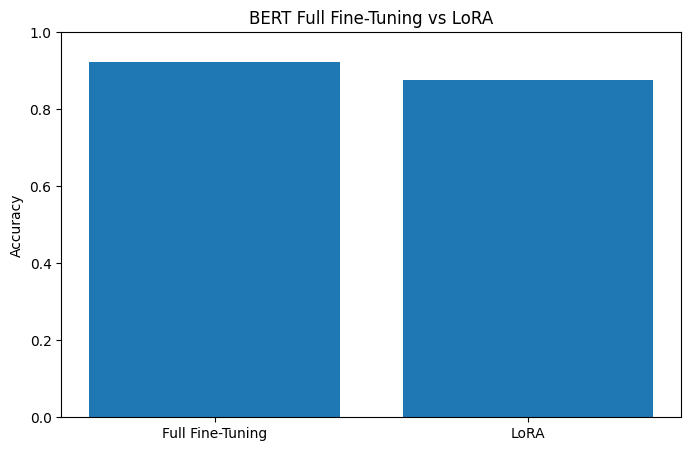

In [35]:
import matplotlib.pyplot as plt

methods = ["Full Fine-Tuning", "LoRA"]

accuracies = [
    full_results["eval_accuracy"],
    lora_results["eval_accuracy"]
]

plt.figure(figsize=(8, 5))

plt.bar(methods, accuracies)

plt.ylabel("Accuracy")
plt.title("BERT Full Fine-Tuning vs LoRA")

plt.ylim(0, 1)

plt.show()

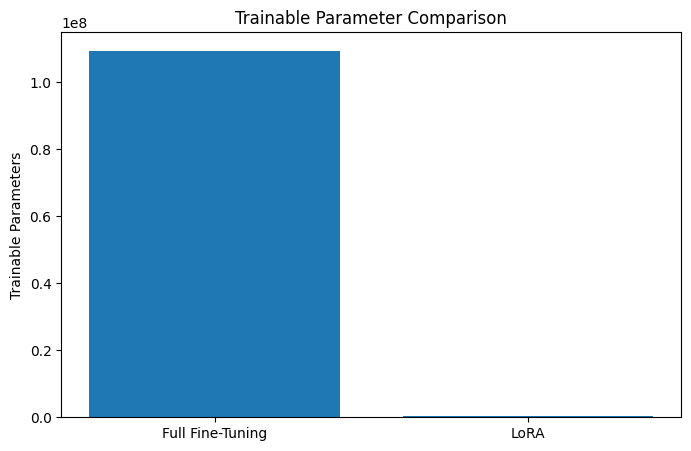

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    methods,
    [trainable_params, lora_trainable_params]
)

plt.ylabel("Trainable Parameters")
plt.title("Trainable Parameter Comparison")

plt.show()

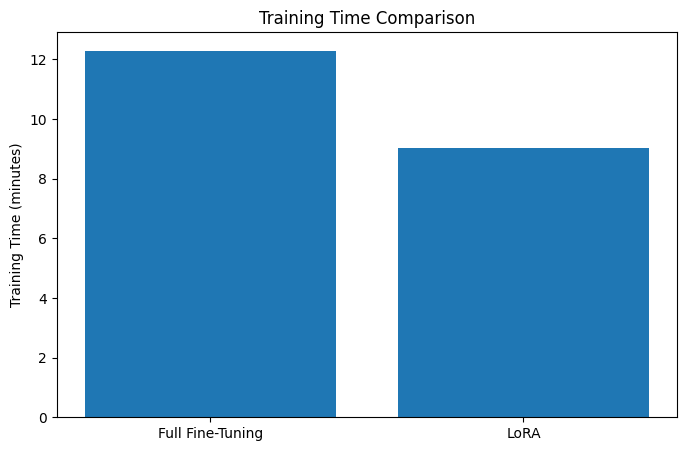

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    methods,
    [full_training_time / 60, lora_training_time / 60]
)

plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")

plt.show()

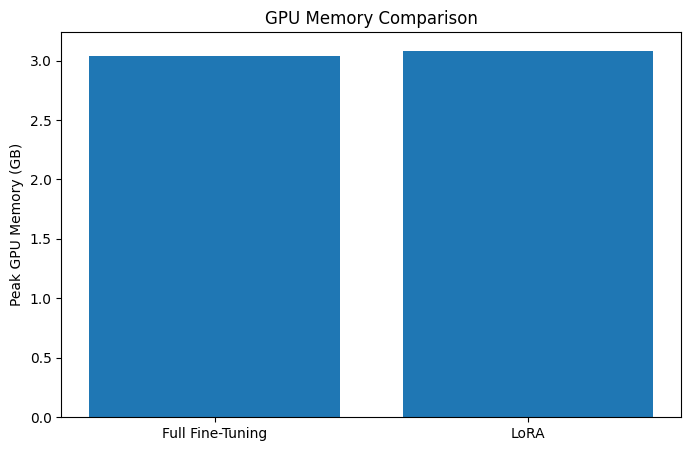

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    methods,
    [peak_memory, lora_peak_memory]
)

plt.ylabel("Peak GPU Memory (GB)")
plt.title("GPU Memory Comparison")

plt.show()

In [39]:
comparison.to_csv(
    "bert_full_vs_lora_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


Task **2**

In [40]:
from peft import LoraConfig, get_peft_model, TaskType
import time
import torch
import pandas as pd

In [41]:
lora_r_values = [8, 16]
lora_alpha_values = [16, 32]

print("Rank values:", lora_r_values)
print("Alpha values:", lora_alpha_values)

Rank values: [8, 16]
Alpha values: [16, 32]


In [42]:
hyperparameter_array = []

for r in lora_r_values:
    for alpha in lora_alpha_values:
        hyperparameter_array.append({
            "r": r,
            "alpha": alpha
        })

print(hyperparameter_array)

[{'r': 8, 'alpha': 16}, {'r': 8, 'alpha': 32}, {'r': 16, 'alpha': 16}, {'r': 16, 'alpha': 32}]


In [43]:
results = []

In [45]:
for config_values in hyperparameter_array:

    r = config_values["r"]
    alpha = config_values["alpha"]

    print("=" * 60)
    print(f"Training LoRA: r={r}, alpha={alpha}")
    print("=" * 60)

    # Fresh BERT model
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    # LoRA configuration
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r,
        lora_alpha=alpha,
        lora_dropout=0.1,
        target_modules=["query", "value"],
        bias="none",
        modules_to_save=["classifier"]
    )

    # Apply LoRA
    model_lora = get_peft_model(
        base_model,
        lora_config
    )

    # Count parameters
    total_params = sum(
        p.numel()
        for p in model_lora.parameters()
    )

    trainable_params = sum(
        p.numel()
        for p in model_lora.parameters()
        if p.requires_grad
    )

    trainable_percentage = (
        trainable_params / total_params
    ) * 100

    print("Total parameters:", total_params)
    print("Trainable parameters:", trainable_params)
    print("Trainable %:", trainable_percentage)

    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"./lora_r{r}_alpha{alpha}",

        eval_strategy="epoch",

        save_strategy="no",

        learning_rate=2e-5,

        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,

        num_train_epochs=2,

        weight_decay=0.01,

        logging_steps=100,

        report_to="none",

        fp16=torch.cuda.is_available()
    )

    # Trainer
    trainer = Trainer(
        model=model_lora,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_validation,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    # Start timer
    start_time = time.perf_counter()

    trainer.train()

    end_time = time.perf_counter()

    training_time = end_time - start_time

    # GPU memory
    if torch.cuda.is_available():
        peak_memory = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )
    else:
        peak_memory = 0

    # Test evaluation
    evaluation = trainer.evaluate(tokenized_test)

    # Store results
    results.append({
        "Rank (r)": r,
        "Alpha": alpha,
        "Total Parameters": total_params,
        "Trainable Parameters": trainable_params,
        "Trainable %": trainable_percentage,
        "Training Time (min)": training_time / 60,
        "GPU Memory (GB)": peak_memory,
        "Accuracy": evaluation["eval_accuracy"],
        "Precision": evaluation["eval_precision"],
        "Recall": evaluation["eval_recall"],
        "F1 Score": evaluation["eval_f1"]
    })

    print("Accuracy:", evaluation["eval_accuracy"])
    print("F1:", evaluation["eval_f1"])
    print("Training time:", training_time / 60, "minutes")
    print("GPU memory:", peak_memory, "GB")

Training LoRA: r=8, alpha=16


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 109780228
Trainable parameters: 296450
Trainable %: 0.2700395193203643


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.370606,0.329414,0.866000,0.871774,0.859984,0.865839
2,0.337669,0.316434,0.874000,0.859542,0.895784,0.877289


...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 110075140
Trainable parameters: 591362
Trainable %: 0.537234837947969


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.330047,0.299104,0.875600,0.892206,0.856006,0.873731
2,0.310699,0.283082,0.884800,0.875290,0.898966,0.886970


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.310699,0.284523,2,0.882880,0.862906,0.910400,0.886017


Accuracy: 0.88288
F1: 0.8860168171909063
Training time: 8.951716423466678 minutes
GPU memory: 3.5028796195983887 GB


In [46]:
evaluation_matrix = pd.DataFrame(results)

evaluation_matrix

,Rank (r),Alpha,Total Parameters,Trainable Parameters,Trainable %,Training Time (min),GPU Memory (GB),Accuracy,Precision,Recall,F1 Score
0,8,16,109780228,296450,0.270040,9.012392,3.496593,0.86952,0.848236,0.90008,0.873389
1,8,32,109780228,296450,0.270040,8.972356,3.497570,0.88268,0.867537,0.90328,0.885048
2,16,16,110075140,591362,0.537235,8.985654,3.500926,0.87500,0.863682,0.89056,0.876915
3,16,32,110075140,591362,0.537235,8.951716,3.502880,0.88288,0.862906,0.91040,0.886017


In [47]:
best_accuracy = evaluation_matrix.loc[
    evaluation_matrix["Accuracy"].idxmax()
]

best_accuracy

,3
Rank (r),1.600000e+01
Alpha,3.200000e+01
Total Parameters,1.100751e+08
Trainable Parameters,5.913620e+05
Trainable %,5.372348e-01
Training Time (min),8.951716e+00
GPU Memory (GB),3.502880e+00
Accuracy,8.828800e-01
Precision,8.629057e-01
Recall,9.104000e-01


In [48]:
best_f1 = evaluation_matrix.loc[
    evaluation_matrix["F1 Score"].idxmax()
]

best_f1

,3
Rank (r),1.600000e+01
Alpha,3.200000e+01
Total Parameters,1.100751e+08
Trainable Parameters,5.913620e+05
Trainable %,5.372348e-01
Training Time (min),8.951716e+00
GPU Memory (GB),3.502880e+00
Accuracy,8.828800e-01
Precision,8.629057e-01
Recall,9.104000e-01


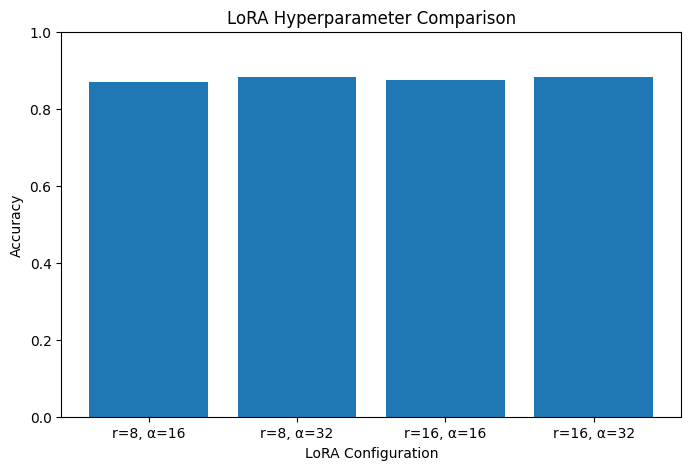

In [49]:
import matplotlib.pyplot as plt

labels = [
    f"r={r}, α={alpha}"
    for r, alpha in zip(
        evaluation_matrix["Rank (r)"],
        evaluation_matrix["Alpha"]
    )
]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    evaluation_matrix["Accuracy"]
)

plt.xlabel("LoRA Configuration")
plt.ylabel("Accuracy")
plt.title("LoRA Hyperparameter Comparison")

plt.ylim(0, 1)
plt.show()

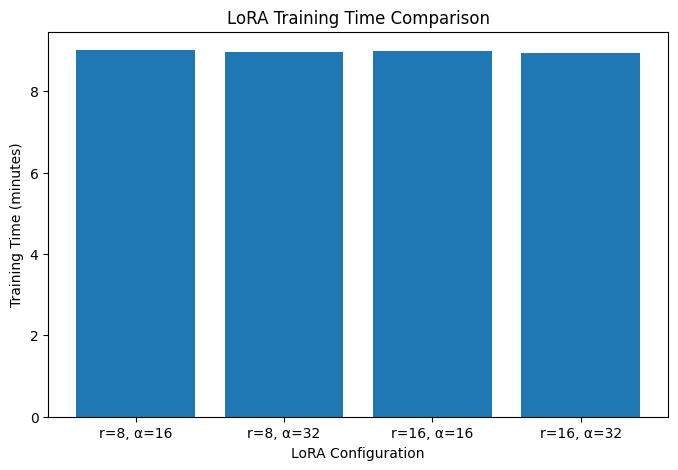

In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    labels,
    evaluation_matrix["Training Time (min)"]
)

plt.xlabel("LoRA Configuration")
plt.ylabel("Training Time (minutes)")
plt.title("LoRA Training Time Comparison")

plt.show()

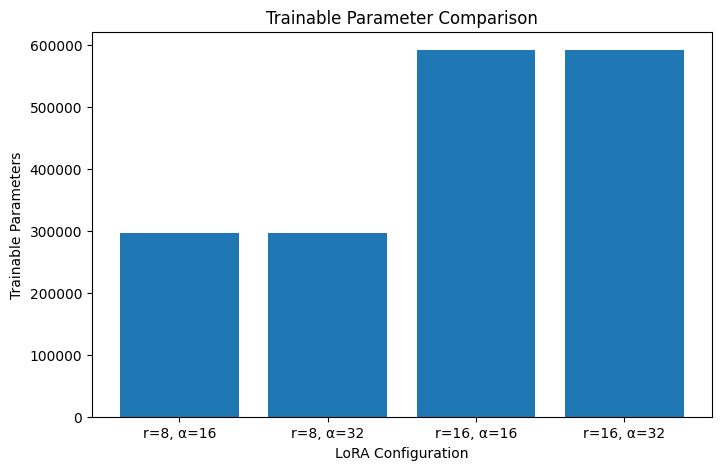

In [51]:
plt.figure(figsize=(8,5))

plt.bar(
    labels,
    evaluation_matrix["Trainable Parameters"]
)

plt.xlabel("LoRA Configuration")
plt.ylabel("Trainable Parameters")
plt.title("Trainable Parameter Comparison")

plt.show()

In [52]:
evaluation_matrix.to_csv(
    "LoRA_hyperparameter_results.csv",
    index=False
)

print("Evaluation matrix saved.")

Evaluation matrix saved.
